# 09: your own analysis

### CAJAL NEUROMICS summer school, Bordeaux 2026 · a spatial metabolomics primer

*Luca Fusar Bassini · notebook 9 of 9 · the open one*

---

This is the last notebook, and it is almost empty on purpose. The eight before it walked
you down a fixed path: load the two sections, look at lipids in space, normalize, embed,
cluster into lipizones, transfer those labels across conditions, test which lipids change
in pregnancy, and read those changes against the transcriptome. Every step was scaffolded.
You pressed buttons whose insides you had already seen unrolled.

Now the scaffold comes off. You pick a question, you choose the tools, you run the analysis,
and you defend the result. That is what doing science actually feels like, and it is the
single most useful thing you can practice this week. A working pipeline is not the goal.
A good question, answered honestly, is.

You will not be alone. You have the `cajal_lipidomics` helpers, you have the real data,
you have the eight finished notebooks as a reference library, and you have Claude Code
sitting next to you to write code on demand. The skill this notebook trains is not typing.
It is steering: deciding what to ask, judging what comes back, and noticing when something
is wrong.

## the callouts, one last time

- 🔬 **TASK**: something you do (write or run code).
- 💡 **HINT**: a nudge when you are stuck.
- ❓ **QUESTION**: pause and think; no code required.
- ⚠️ **CHECKPOINT**: what you should see if it worked. If your screen disagrees, stop and fix it.

🔬 **TASK.** Run the next cell to load the stack and the data. You have run this exact
header in every notebook, so it should feel routine by now.

In [1]:
# the scientific-Python stack, the course helpers, the data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import anndata as ad
import cajal_lipidomics as cl
from cajal_lipidomics import analysis, plotting, embedding, multimodal, annotation
from cajal_lipidomics.style import set_style
set_style()  # the course-wide figure look: clean axes, vector text, fixed font sizes

# one global seed so every number and figure below is reproducible
SEED = 0
np.random.seed(SEED)

# the substrate: two coronal sections at the same plane (AP ~6.5),
# one control ('naive') and one pregnant, 174768 pixels x 173 lipids
adata = ad.read_h5ad("../../data/sections_pair.h5ad")
print(f"loaded {adata.n_obs} pixels x {adata.n_vars} lipids")
print("conditions:", adata.obs["Condition"].value_counts().to_dict())

loaded 174768 pixels x 173 lipids
conditions: {'pregnant': 90447, 'naive': 84321}


⚠️ **CHECKPOINT.** You should see `loaded 174768 pixels x 173 lipids` and the two
conditions, `naive` (control) and `pregnant`, with about 84k and 90k pixels. No red error.
If you get a `FileNotFoundError`, check the relative path to `data/sections_pair.h5ad`
from wherever this notebook lives.

## what you already know how to do

Before you invent something new, take stock of the machine you have built. Here is the
whole pipeline in one place, each step paired with the helper that performs it. Treat this
as your menu. Almost any project you propose will be a recombination of these pieces.

**The data.** `adata.X` is the uMAIA-normalized lipid intensity, one row per pixel, one
column per lipid (`adata.var_names`). A pixel is one MALDI laser spot, roughly 25 micrometres,
not one cell: it mixes cell bodies, axons, dendrites, and glia. `adata.obs` carries the
metadata you will lean on most: `Condition` (naive vs pregnant), `SectionID`, the Allen
atlas region `acronym` (and its color `allencolor`, its readable `name`), the lipizone labels
`lipizone_names` and `lipizone_color`, the `subclass_name`, and the spatial coordinates
`zccf`, `yccf`, `xccf` plus a precomputed `tsne1`/`tsne2` embedding. One caveat for project
planning: `adata.obs` also carries a `division` column, but in this two-section subset it is
uniformly `General` across all 174768 pixels, so it carries no information. Do not build a
project on it; reach for `acronym` (and group acronyms by hand) when you need anatomy.

**Look at the data in space.** `plotting.spatial_lipid(adata, "PC 38:6")` paints one lipid
on the tissue across both sections with a shared colour scale. `plotting.spatial_categorical(adata)`
paints the pixels by lipizone (or by Allen region with `color_key="allencolor"`). Looking
first is not optional; it is the teaching.

**Annotate a peak.** A MALDI measurement is a mass, not a name. `annotation.match_lcms`
and `annotation.plot_ppm_match` match an observed m/z to a reference lipid within a
parts-per-million window, and draw the match so you can see why it holds.

**Embed and cluster.** `embedding.seeded_nmf(adata.X)` factors the lipids into a handful of
non-negative, additive programs (the parts-based recipe). `embedding.harmonize` removes the
section-to-section batch offset in that program space, but only for clustering and label
transfer, never for the statistics. `embedding.leiden_clusters` cuts the neighbour graph
into communities, the data-driven territories the paper calls lipizones.

**Transfer labels.** `embedding.knn_transfer` copies cluster labels from the control brain
onto the pregnant brain through the shared, harmonized embedding, so the two conditions speak
the same anatomical language.

**Test what changes.** `analysis.differential_lipids(adata, "Condition", "naive", "pregnant")`
runs a Wilcoxon rank-sum test per lipid with a Benjamini-Hochberg correction, returning a
log2 fold change, a corrected q-value, and a significance flag. `plotting.volcano` draws it.
`analysis.marker_lipids` finds the lipids that define each cluster.

**Score and interpret.** `analysis.myelination_score` sums the sphingolipids per pixel as a
myelin proxy. `analysis.membrane_remodeling_score` sums the fold changes per region.
`multimodal.region_change_matrix` builds the per-region pregnancy change, and the rest of
`multimodal` (gene programs, XGBoost prediction, SHAP) asks which genes track which lipid
changes, using the MERFISH region-by-gene table.

That is the toolbox. Now we use a sliver of it on one tiny question, end to end, as a model
for your own.

## one worked mini-example, start to finish

A good project is a loop: ask, look, test, read, doubt. Watch the loop run once on a
question small enough to fit in three cells, then you will repeat it on a question of your own.

**The question.** The caudoputamen (Allen acronym `CP`, the dorsal striatum) is a large,
easy-to-find grey-matter structure that sits squarely in both of our sections. Does its
lipid composition change in pregnancy?

**Why it matters.** The striatum is rich in dopaminergic signalling and its membranes turn
over with activity. If pregnancy remodels membranes broadly, a big homogeneous region like
`CP` is where we have the most pixels and therefore the most statistical power to see it.

**The strategy.** Subset to `CP` pixels, run the same Wilcoxon plus Benjamini-Hochberg test
we use everywhere, and read the volcano.

🔬 **TASK.** Run the next cell. We subset, then count what we are working with.

In [2]:
# subset to one Allen region present in both conditions
region = "CP"  # caudoputamen / dorsal striatum
cp = adata[adata.obs["acronym"] == region].copy()

n_by_cond = cp.obs["Condition"].value_counts().to_dict()
print(f"{region}: {cp.n_obs} pixels  ->  {n_by_cond}")

CP: 12565 pixels  ->  {'pregnant': 7064, 'naive': 5501}


⚠️ **CHECKPOINT.** You should see about 12565 `CP` pixels, roughly 5501 control and
7064 pregnant. Both conditions are well represented, so the comparison is fair.

🔬 **TASK.** Run the differential test. The helper does, per lipid, exactly the Wilcoxon
rank-sum you saw unrolled in the case-control notebook: rank all the intensities, ask whether
the pregnant ranks sit systematically above or below the control ranks, then correct every
p-value for the fact that we tested 173 lipids at once.

In [3]:
# Wilcoxon rank-sum per lipid + Benjamini-Hochberg, control ('naive') vs pregnant
diff = analysis.differential_lipids(cp, "Condition", "naive", "pregnant")

n_sig = int(diff["sig"].sum())
print(f"{n_sig} of {len(diff)} lipids change significantly in {region} "
      f"(|log2FC| > 0.2 and q < 0.05)")
print("\nmost UP in pregnant:")
print(diff.sort_values("log2fc", ascending=False).head(3)[["lipid", "log2fc", "qval"]].to_string(index=False))
print("\nmost DOWN in pregnant:")
print(diff.sort_values("log2fc").head(3)[["lipid", "log2fc", "qval"]].to_string(index=False))

41 of 173 lipids change significantly in CP (|log2FC| > 0.2 and q < 0.05)

most UP in pregnant:
     lipid   log2fc  qval
   PA 34:1 0.585466   0.0
SM 38:1;O2 0.549239   0.0
  LPE 22:6 0.472033   0.0

most DOWN in pregnant:
         lipid    log2fc          qval
HexCer 36:1:O2 -0.887415  0.000000e+00
       PC 42:1 -0.502964  0.000000e+00
       PC 40:1 -0.466434 3.391493e-297


⚠️ **CHECKPOINT.** You should read that **41 of 173 lipids** change significantly in
`CP`. `PA 34:1` rises most in pregnancy (log2FC about +0.59, so roughly a 1.5-fold increase),
while `HexCer 36:1:O2` falls most (log2FC about -0.89, close to halved). Phosphatidic acid is
a signalling and membrane-curvature lipid, and a hexosylceramide is a myelin building block,
so even this one-region glance hints at coordinated membrane remodeling. Now see it.

🔬 **TASK.** Draw the volcano. Each point is a lipid: fold change left-to-right, statistical
confidence bottom-to-top. The dashed lines are our thresholds; red points clear both.

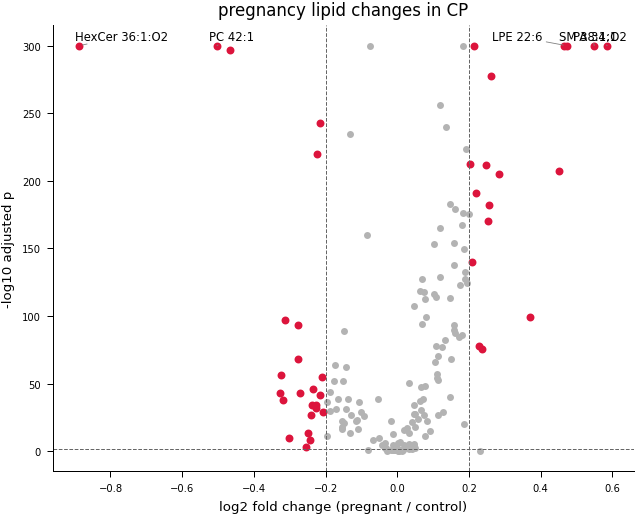

In [4]:
# the volcano: log2 fold change vs -log10 corrected p
# the helper draws the points and the threshold lines; we add the labels ourselves
# so we can de-overlap them. many of our top hits pile up at the y=300 ceiling
# (q rounds to 0, so -log10 q hits the clip), and naive centred labels there fuse
# into an illegible blob. that breaks the course rule that a figure read from across
# the room, so we keep the labels few and pull them apart with adjustText.
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(5.5, 4.5))
# label_col=None: the helper paints the grey/crimson points and the dashed thresholds,
# but draws no text, so it cannot collide with anything
plotting.volcano(diff, label_col=None, ax=ax,
                 title=f"pregnancy lipid changes in {region}")

# label only the 5 strongest movers, the names a reader actually needs
top = diff[diff["sig"]].reindex(
    diff[diff["sig"]]["log2fc"].abs().sort_values(ascending=False).index).head(5)
y_top = -np.log10(top["qval"].clip(lower=1e-300))
texts = [ax.text(fc, yy, name, fontsize=7, ha="center")
         for fc, yy, name in zip(top["log2fc"], y_top, top["lipid"])]
# adjust_text nudges the labels off each other and off the points, drawing a thin
# leader line back to the dot each one names. now every label is readable.
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.5", lw=0.5))

plt.tight_layout()
plt.show()

That is the whole loop: a question, a subset, a test, a picture, a one-line biological
read. It took three cells. Your project is the same loop on a question you care about, run
longer and pushed harder.

❓ **QUESTION.** Before you move on, stress-test this result the way a reviewer would. We
have **exactly one control section and one pregnant section**. The Wilcoxon here compares
pixels *within* `CP`, not biological replicates. So the p-value answers can these two
tissue slabs be told apart, not is this difference reproducible across pregnant mice. What
follow-up would start to separate real biology from a two-section fluke? Hold that thought:
it is the kind of what could go wrong you must write into your own plan.

## the planning template

Every good analysis starts on paper, not in code. Before you write a single line, fill in
the six boxes below. They are the same six a grant reviewer, a thesis committee, or your own
future self will ask about. Filling them honestly is half the work, and it is the half that
stops you from spending an afternoon computing something nobody asked for.

🔬 **TASK.** Copy the template in the next cell, then replace every `...` with your own
words. Keep it short. One or two sentences per box is plenty. Do this before you touch the data.

In [5]:
# ===========================  MY PROJECT PLAN  ===========================
#
# QUESTION
#   The one specific thing I want to know.
#   ...
#
# WHY IT MATTERS
#   What it would change about how we read the brain, the data, or the paper.
#   ...
#
# DATA
#   Exactly which pixels, lipids, regions, conditions, or external tables I will use,
#   and where they live (adata.obs columns? the MERFISH parquet? a METASPACE id?).
#   ...
#
# STRATEGY
#   The sequence of steps and which cl.<helper> performs each one.
#   ...
#
# WHAT RESULT WOULD ANSWER IT
#   The concrete number, figure, or comparison that says yes or no. Decide the
#   threshold NOW, before you see the answer, so you cannot move the goalposts.
#   ...
#
# WHAT COULD GO WRONG
#   Batch vs biology (we have only 2 sections), too few pixels, a confound, a
#   registration error, an annotation that is actually isobaric. Name the failure
#   mode you most fear, and how you would detect it.
#   ...
# =========================================================================
print("plan written. now, and only now, open the data.")

plan written. now, and only now, open the data.


💡 **HINT.** The hardest box is usually *what result would answer it*. If you cannot
name the figure or the number in advance, your question is still too vague. Narrow it until
the answer is a single plot you can imagine before you draw it.

## three starter directions

If you have your own question, skip these and go fill in the template. If you want a running
start, here are three concrete directions, each phrased as a prompt you could hand to Claude
Code or follow by hand. Pick one, make it yours, and write the plan for it.

### direction A: reproduce a panel from the paper

The biorxiv (Fusar Bassini et al., *The lipidomic architecture of the mouse brain*, 2025)
makes specific, checkable claims. One headline: in pregnancy, the myelin marker
**HexCer 42:2;O2** goes *up* across white-matter territories, suggesting widespread adaptive
myelination. The paper reports an average log2FC of about +0.38 for that lipid across white
matter, computed on its full pregnancy cohort (three pregnant and three control females) with
its Bayesian model. We have only one control and one pregnant section and a simpler Wilcoxon
test, so treat that +0.38 as a paper claim we have *not* yet verified here, and rebuild the
check ourselves.

The trap to avoid: the lipid is named `HexCer 42:2;O2` in `adata.var_names`, with the `;O2`
suffix (the two extra oxygens of the hydroxy-ceramide backbone). Plain `HexCer 42:2` is not a
column and will raise an error. And do not reach for `adata.obs['division']` to find the white
matter: in this two-section subset that field is uniformly `General`, so it carries zero
information. Select white matter by its Allen `acronym` instead. The white-matter tracts present
in both sections include `ccb` (corpus callosum body), `fi` (fimbria), `int` (internal capsule),
`alv` (alveus), `ec` (external capsule), `scwm` (subcortical white matter), `cing` (cingulum),
`opt` (optic tract), `em`, `sm`, `st`, and `fx`. The worked cell below does exactly this check;
read it, then make it yours (different lipid, different claim, a spatial map alongside).

> *Prompt.* "Using `adata` and the `cajal_lipidomics` helpers, test whether `HexCer 42:2;O2`
> (note the `;O2` suffix, the exact `var_names` string) is higher in pregnant than control
> pixels, restricted to white matter. Build the white-matter mask from `adata.obs['acronym']`
> using tract acronyms like `ccb`, `fi`, `int`, `alv`, `ec`, `scwm` (do NOT use the `division`
> field, it is uniformly `General` here). Run `analysis.differential_lipids` on that subset,
> read off the log2FC for `HexCer 42:2;O2`, and draw the lipid in space with
> `plotting.spatial_lipid` side by side for the two conditions. Report the fold change and its
> sign, and say whether the direction matches the paper's reported +0.38."

What result would answer it: a fold change with the same sign as the paper (up in pregnancy),
plus a spatial map where the white matter visibly brightens in the pregnant panel. The
magnitude need not match +0.38 exactly, because our test and cohort differ from the paper's.
The cell below runs this check so you can see the honest number before you extend it.

### direction B: test a hypothesis about one lipid class

Lipid classes have jobs. Sphingolipids (`HexCer`, `Cer`, `SM`) build myelin; the
glycerophospholipids (`PC`, `PE`, `PS`, `PI`) build the bulk bilayer; lysolipids (`LPC`,
`LPE`) and `PA` are signalling and turnover intermediates. Form a hypothesis like
*pregnancy shifts the balance from structural sphingolipids toward turnover lysolipids* and
test it across regions.

> *Prompt.* "Parse every name in `adata.var_names` into its lipid class with a regular
> expression (the class is the token before the first space). For each class, average the
> pregnancy log2 fold change across regions using `multimodal.region_change_matrix`, and
> draw a bar chart of mean change per class with the count of lipids in each. Which classes
> go up, which go down, and is the sphingolipid-vs-lysolipid contrast real?"

What result would answer it: a ranked bar chart of per-class mean change, with the
direction you predicted either confirmed or refuted.

### direction C: explore a region you choose

We looked at `CP`. The brain has 174 Allen regions in these sections. Pick one you find
interesting, the piriform cortex `PIR`, a hippocampal field `CA3`, the lateral hypothalamus
`LHA`, or scan `adata.obs["acronym"].value_counts()` and choose by pixel count. Ask the same
question we asked of `CP`, or a different one: which lipizones live there, what lipids mark
them, how the region changes in pregnancy.

> *Prompt.* "Subset `adata` to Allen region `<your acronym>`, confirm it has at least ~150
> pixels in both conditions, run `analysis.differential_lipids`, draw the volcano with
> `plotting.volcano`, and also show which lipizones (`lipizone_names`) compose the region
> with a value-count bar. Write two sentences on what the top changing lipids suggest
> biologically."

What result would answer it: a volcano for your region plus its lipizone composition, and a
short, honest interpretation.

### or: bring your own data

If you arrived with your own MALDI, lipidomics, or spatial dataset, the best possible
project is to run this pipeline on it. The helpers assume an `AnnData` with pixels in rows,
features in columns, and metadata in `.obs`. If you can shape your data into that, almost
every function above will work. Talk to me early so we pick a tractable slice for the week.

🔬 **TASK.** Run direction A once, end to end, so the paper claim stops being a claim and
becomes a number you watched come out of code. We build a white-matter mask from Allen
acronyms, run the same Wilcoxon plus Benjamini-Hochberg test, and read off the log2FC for
`HexCer 42:2;O2`.

In [6]:
# direction A, worked: is the myelin marker HexCer 42:2;O2 up in pregnant white matter?
# 1) build the white-matter mask from Allen acronyms (NOT from 'division', which is
#    uniformly 'General' in this two-section subset and carries no information)
wm_acronyms = ["ccb", "ccs", "ccg", "fi", "int", "alv", "ec", "scwm",
               "cing", "opt", "em", "sm", "st", "fx", "or", "arb"]
wm_mask = adata.obs["acronym"].isin(wm_acronyms).values
wm = adata[wm_mask].copy()
print(f"white matter: {wm.n_obs} pixels  ->  {wm.obs['Condition'].value_counts().to_dict()}")

# 2) same Wilcoxon + Benjamini-Hochberg test, control ('naive') vs pregnant
lipid = "HexCer 42:2;O2"  # exact var_names string, with the ;O2 suffix
assert lipid in adata.var_names, f"{lipid!r} not in var_names"  # the trap, made loud
wm_diff = analysis.differential_lipids(wm, "Condition", "naive", "pregnant")
row = wm_diff[wm_diff["lipid"] == lipid].iloc[0]

# 3) read off OUR number and compare its SIGN to the paper's reported +0.38
paper_log2fc = 0.38  # paper claim, full cohort + Bayesian model, NOT computed here
same_sign = np.sign(row["log2fc"]) == np.sign(paper_log2fc)
print(f"\n{lipid} in white matter (our 2-section Wilcoxon):")
print(f"  log2FC = {row['log2fc']:+.3f}   q = {row['qval']:.2e}   significant = {bool(row['sig'])}")
print(f"  paper reports about {paper_log2fc:+.2f} (full cohort); same direction? {same_sign}")

white matter: 15342 pixels  ->  {'pregnant': 8208, 'naive': 7134}

HexCer 42:2;O2 in white matter (our 2-section Wilcoxon):
  log2FC = +0.329   q = 4.61e-254   significant = True
  paper reports about +0.38 (full cohort); same direction? True


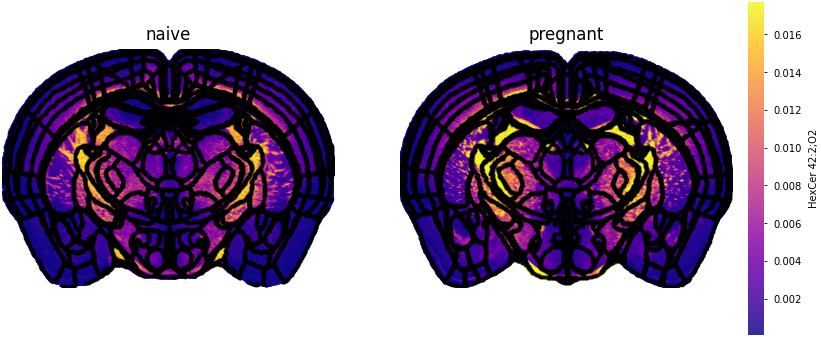

In [7]:
# the number is only half the answer; now look. paint HexCer 42:2;O2 on both sections
# with the shared colour scale, so a brighter pregnant panel is a brightening you can see.
plotting.spatial_lipid(adata, lipid)
plt.show()

⚠️ **CHECKPOINT.** In our two sections `HexCer 42:2;O2` comes out **up** in pregnant white
matter, log2FC about **+0.33** with a tiny q, the *same direction* as the paper's reported
+0.38. That is a real, if partial, replication: the sign matches, the magnitude is in the
same ballpark, but we used one section per condition and a Wilcoxon, not the paper's
six-mouse Bayesian model, so we have confirmed the direction, not the exact effect size. The
spatial map should show the white-matter tracts a touch brighter in the pregnant panel,
which is the picture behind the number. This is the honest version of the claim: a
verification path that runs, with the limits stated out loud. Now do the same for a claim of
your own.

## using Claude Code well

You have an AI coding assistant for this project. Used well it is the best lab partner you
will ever have. Used badly it is a confident liar that wastes your afternoon. The difference
is entirely in how you supervise it. Four rules.

**Read what it writes, every line.** Never run code you do not understand. If the assistant
produces a block you cannot follow, ask it to explain that block before you run it, or ask it
to rewrite it more simply. The unrolled, transparent style of these notebooks exists so that
you *can* read the code. Keep that standard for the code the assistant gives you.

**Verify against reality, not against its confidence.** The assistant will state results in a
sure voice whether or not they are true. Check them. Did the cell actually run, or did it
error and the assistant move on? Does the pixel count match the checkpoint? Does the fold
change have a plausible sign and size? Print intermediate shapes and a few values. A number
you have not seen printed by code that ran is not a result, it is a guess.

**Iterate in small steps.** Ask for one cell at a time, run it, look at the output, then ask
for the next. A giant block that does everything at once is impossible to debug and easy to
get subtly wrong. Small steps with a printout after each are how you keep control.

**Give it the context it needs.** Tell it the data lives in `adata`, with `adata.X` as
uMAIA-normalized lipids and the `.obs` columns listed above, and that the `cajal_lipidomics`
helpers exist (point it at the source in `src/cajal_lipidomics/`). Tell it we have exactly two
sections and no biological replicates, so it does not propose a replicate-level statistic we
cannot run. The more precisely you frame the task, the better the code.

❓ **QUESTION.** When the assistant hands you a result, what are the three quickest checks you
can run to catch a lie? (Mine: did the cell run without error, does a printed shape match what
I expect, and does the headline number have a sign and magnitude that make biological sense.)

## your turn

Below is a blank cell. Fill in your plan above first, then start your analysis here, one
small step at a time. Add as many cells as you need. Print as you go. Plot early and often:
in this course, the plots are the thinking, not the decoration.

🔬 **TASK.** Write your first analysis step.

In [8]:
# your analysis starts here
# (plan first, then one small step at a time, printing and plotting as you go)


## the presentation rubric

On the last day you present what you found, in a short talk plus one figure. You are not
graded on how much code you wrote or how fancy the method was. You are graded on whether you
did honest science. Aim for these five things.

1. **A clear question.** State it in one sentence at the top. We should know exactly what you
   set out to learn before you show us anything.
2. **The right picture.** One main figure that answers the question, made to the course style
   (clean axes, labelled, a colour scale with a unit). It should be readable from across the
   room and stand on its own.
3. **Honest numbers.** Every number you claim came from code that ran on the real data. No
   rounding away the inconvenient, no quoting a result you did not actually compute. Show the
   fold change, the count, the p-value as they came out.
4. **A biological reading.** Pair the result with what it means, in calibrated language.
   *Suggests*, *is consistent with*, *at a correlative level*, not *proves*. One good
   sentence of interpretation beats a paragraph of hedging.
5. **What could go wrong, named out loud.** Tell us the weakness you know about: the two-section
   limit, a small pixel count, a possible batch effect, an isobaric annotation. Owning the
   caveat is the strongest thing you can do. It is what separates a result from a claim.

💡 **HINT.** A two-minute talk that says *here is my one question, here is the one figure
that answers it, here is what it means, and here is what I am not sure about* will land far
better than ten rushed slides. Less, but solid.

## a last word

You started this course pressing buttons whose insides were hidden. You are ending it by
choosing which buttons to press, and why. That shift, from following a recipe to asking a
question, is the whole point. The lipid brain is enormous and barely mapped. Most of what is
in these 173 lipids across 174768 pixels has never been looked at carefully by anyone. Some
of it is waiting for you.

Keep the habits this course tried to build: look at the data before you model it, unroll a
method until you understand it, pair every number with its meaning, and say plainly what you
are unsure of. Those habits outlast any one pipeline.

If you take this further, into your own data, your own thesis, a question that will not let
you go, I would genuinely like to hear about it. Write to me. The atlas is a starting point,
not a finish line, and the best uses of it are the ones I have not thought of yet.

Thank you for the week. Go find something.

*Luca Fusar Bassini · luca.fusarbassini@epfl.ch*